In [ ]:
!pip install diffusers transformers torch gradio accelerate -q

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
print("Libraries imported successfully!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Libraries imported successfully!


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"
pipeline = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16 if device == "cuda" else torch.float32)
pipeline = pipeline.to(device)
print("Stable Diffusion pipeline loaded successfully!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion pipeline loaded successfully!


In [ ]:
def generate_image(prompt):
  if prompt.strip() =="" or not prompt:
    return "Please write a prompt"

  print("Generating image__ Please Wait")
  image = pipe(prompt,num_inference_steps=30).images[0]
  return image

test_prompt = "Nothing"
result= generate_image(test_prompt)
result

Generating image__ Please Wait


NameError: name 'pipe' is not defined

Generating: A majestic lion standing on a rock at sunset, highly detailed


  0%|          | 0/40 [00:00<?, ?it/s]

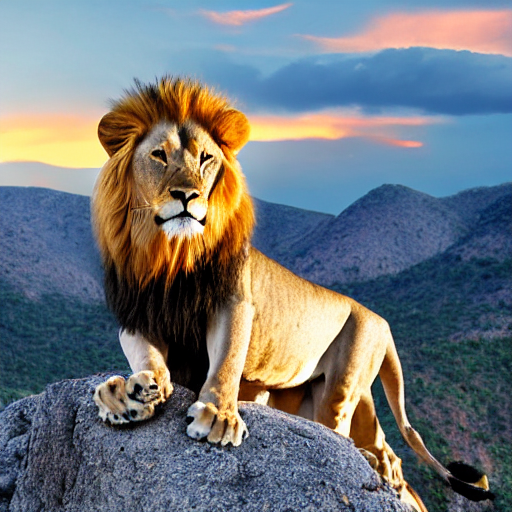

In [ ]:
def generate_image(prompt, steps=40):
    print(f"Generating: {prompt}")
    image = pipe(prompt, num_inference_steps=steps, guidance_scale=7.5).images[0]
    return image


result = generate_image("A majestic lion standing on a rock at sunset, highly detailed")
result

In [ ]:
model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

print("✅ Model loaded successfully!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Model loaded successfully!


In [ ]:
import gradio as gr

def generate_image(prompt,negative_prompt="",steps=40,guidance=7.5):
    if not prompt:
       return "Please enter a prompt!", None
    print("Generating image...")
    image = pipe(
      prompt,
      negative_prompt = negative_prompt,
      num_inference_steps=int(steps),
      guidance_scale=guidance
      ).images[0]

    return "Image generated successfully!", image

#Create web Interface
interface = gr.Interface(
      fn=generate_image,
      inputs=[
          gr.Textbox(lines=3, placeholder="A beautiful landscape at sunset..",label="Your Prompt"),
          gr.Textbox(lines=2, placeholder="blurry,ugly, low quality",label = "Negative Prompt(optional)"),
          gr.Slider(20,60, value=40, step=5, label="Quality Steps"),
          gr.Slider(1,15,value=7.5,step=0.5,label="Creativity Level")
      ],
      outputs=[
          gr.Textbox(label="Status"),
          gr.Image(label="Generated Image")
      ],
      title="AI Image Generator - First Year Project.V1.O",
      description="Enter a prompt and generate images ",
      examples=[
          ["A Cute cat wearing sunglasses on a beach","blurry",40,8],
          ["Futuristic cyberpunk city at night","dark,low quality",50,9],
      ]
  )
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dac9aec7998b8272a0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr

def hello(name):
    return "Hello " + name + "!"

gr.Interface(fn=hello, inputs="text", outputs="text", title="Test").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e698cd20b3860784e0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
print("gradio imported successfully")

gradio imported successfully


In [ ]:
import gradio as gr
from datetime import datetime

def generate_image(prompt,negative_prompt="",steps=40,guidance=7.5):
    if not  prompt or prompt.strip()=="":
       return "Please enter a prompt!",None ,None

    print("Generating...")
    image = pipe(
        prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=int(steps),
        guidance_scale=guidance
    ).images[0]

    #create filename for download
    filename = f"generated_image_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"

    return "Success!",image,image  #Return image for preview and download

interface = gr.Interface(
    fn = generate_image,
    inputs=[
        gr.Textbox(lines=2, placeholder="Describe your image...", label="Prompt"),
        gr.Textbox(lines=2, placeholder="Things to avoid...", label="Negative Prompt"),
        gr.Slider(20, 60, value=40, step=5, label="Quality Steps"),
        gr.Slider(1, 15, value=7.5, step=0.5, label="Creativity")
    ],
    outputs=[
        gr.Textbox(label="Status"),
        gr.Image(label="Generated Image"),
        gr.Image(label="Download Image")
    ],
    title="My AI Image Generator.V2.O",
    description="First Year AI Engineering Project ",
    examples =[
        ["A majestic tiger in the jungle ","blurry",45,8],
        ["Cyberprunk city at night","dark",50,9]
    ]
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cece85b47193399ac2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from datetime import datetime

def generate_image(prompt, negative_prompt="",steps=40, guidance=7.5):
    if not prompt or prompt.strip() =="":
        return "Please enter a prompt!",None,None



In [ ]:
import gradio as gr
from datetime import datetime
import os

# Create a folder to save images
os.makedirs("generated_images", exist_ok=True)

def generate_image(prompt, negative_prompt="", steps=40, guidance=7.5):
    if not prompt or prompt.strip()=="":
       return "Please enter a prompt!",None,None

    print("Generating..")
    image = pipe(
        prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=int(steps),
        guidance_scale=guidance
    ).images[0]

    #This part used to Save image automatically
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"generated_image_{timestamp}.png"
    image.save(filename)

    return f" Saved as{filename}",image,image
interface = gr.Interface(
    fn = generate_image,
    inputs = [
        gr.Textbox(lines=4,placeholder="Describe the image you have to generate",label="Prompt"),
        gr.Textbox(lines=2,placeholder="Things to avoid",label="Negative Prompt"),
        gr.Slider(20,60,value=40,step=5,label="Quality Steps"),
        gr.Slider(1,15, value=7.5,step=0.5, label="Creativity level")
    ],
    outputs=[
        gr.Textbox(label="Status"),
        gr.Image(label="Generated Image"),
        gr.Image(label="Download Image")
    ],
    title="AI Image Generator.V3.O",
    description="First Year AI Engineering Project-img saved auto",
    examples=[
        ["Doraemon smiling","",45,8],
        ["A beutiful sunset mountain landscape","",50,9]
    ]
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f524a9533d8e99c311.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
print("Current folder contents:")
print(os.listdir("."))

print("\nGenerated images folder:")
print(os.listdir("generated_images"))

Current folder contents:
['.config', '.gradio', 'generated_images', 'sample_data']

Generated images folder:
[]


In [ ]:
import gradio as gr
from datetime import datetime
import os

#Creating folder and history list
os.makedirs("generated_images",exist_ok=True)
history = []

def generate_image(prompt,negative_prompt="",steps=40,guidance=7.5):
    if not prompt or prompt.strip()=="":
        return "Please enter a prompt",None,None,None

    print("Generating...")
    image = pipe(
        prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=int(steps),
        guidance_scale=guidance,
    ).images[0]

    #Save to folder
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"generated_images/ai_image_{timestamp}.png"
    image.save(filename)

    history.append(image)

    return f"Saved :{filename}", image, image, history

interface = gr.Interface(
    fn = generate_image,
    inputs=[
        gr.Textbox(lines=4,placeholder="Describe the image you have to generate",label="Prompt"),
        gr.Textbox(lines=2,placeholder="Things to avoid",label="Negative prompts"),
        gr.Slider(20,60,value=40,step=5,label="Quality steps"),
        gr.Slider(1,15,value=7.5,step=0.5,label="Creativity Level")
    ],
    outputs=[
        gr.Textbox(label="Status"),
        gr.Image(label="Generated Image"),
        gr.Image(label="Download Image"),
        gr.Gallery(label="History",show_label=False)
    ],
    title = "AI Image Generator.V4.O",
    description = "First Year AI Engineering Project | Images are saved automatically",
    examples=[
        ["Doraemon smiling happily","",45,8],
        ["Mother showing the MOON to her child","",50,9]
    ]
)

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://71ce9b0432adedd820.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import os
from datetime import datetime

os.makedirs("generated_images",exist_ok=True)
history =[]

def generate_image(prompt,negative_prompt="",steps=40,guidance=7.5):
    if not prompt or prompt.strip()=="":
        return "Please enter the prompt",None,None,None


    print("Generating...")
    image = pipe(
        prompt,
        negative_prompt = negative_prompt,
        num_inference_steps=int(steps),
        guidance_scale=guidance
    ).images[0]

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"generated_images/AI_image_{timestamp}.png"
    image.save(filename)

    history.append(image)

    return f"Saved:{filename}",image,image,history

interface = gr.Interface(
        fn = generate_image,
        inputs =[
            gr.Textbox(lines =4,placeholder="Describe the image you have to generate",label = "prompt"),
            gr.Textbox(lines = 2,placeholder="What to avoid ",label = "negative_prompt"),
            gr.Slider(20,60,value=40,step=5,label="Quality steps"),
            gr.Slider(1,15,value=7.5,step=0.5,label="Creativity level")
        ],
        outputs=[
            gr.Textbox(label="Status"),
            gr.Image(label="Generated Image"),
            gr.Image(label="Download Image"),
            gr.Gallery(label="History",height=400)
        ],
        title=[
            "AI Image Generator.V5.O"
        ],
        description="Text-to-Image Generation |First year engineering Project ",
        examples=[
            ["A blue cat with a orange lion","",45,8],
            ["A beautiful girl sitting in the garden","",50,7]
        ]
        ,
        theme="Soft",
        # allow_flagging="never"
    )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://211c4f748d53eaa70d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from datetime import datetime
import os

os.makedirs("generated_images",exist_ok=True)
history=[]

def generate_images(prompt,negative_prompt="",steps=40,guidance=7.5,style="Realisitic"):
    if not prompt or prompt.strip()=="":
       return "Please enter a prompt",None,None,None

    #Adding style
    style_prompt = prompt

    if style=="Anime":
      style_prompt = prompt + ",Anime style"
    elif style=="Oil Painting":
      style_prompt = prompt + ",Oil Painting"
    elif style=="Cartoon":
      style_prompt = prompt + ",Cartoon"
    elif style=="Cyberpunk":
      style_prompt = prompt + ",Cyberpunk"
    elif style=="Fantasy":
      style_prompt = prompt + ",Fantasy"


    print("Generating...")
    image=pipe(
        style_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=int(steps),
        guidance_scale=guidance
    ).images[0]

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"generated_images/ai_image_{timestamp}.png"
    image.save(filename)

    history.append(image)

    return f"Saved:{filename}({style} style)",image,image,history

interface = gr.Interface(
    fn = generate_images,
    inputs = [
        gr.Textbox(lines=4,placeholder="Describe the image you have to generate",label="prompt"),
        gr.Textbox(lines=6,placeholder="Thingd to avoid",label="Negative Prompt"),
        gr.Slider(20,60,value=40,step=5,label="Quality Step"),
        gr.Slider(1,15,value=7.5,step=0.5,label="Creativity Level"),
        gr.Dropdown(choices=["Realistic", "Anime", "Oil Painting", "Cartoon", "Cyberpunk", "Fantasy"],
                   value="Realistic", label="Style")
    ],
    outputs=[
        gr.Textbox(label="Status"),
        gr.Image(label="Generated_image"),
        gr.Image(label="Download_image"),
        gr.Gallery(label="History",height=400)
    ],
    title="AI-Image Generator-6.O",
    description="First Year AI engineeing project",
    examples=[
        ["A big brown cat jump over lazy dog","",50,7.5,"Anime"],
        ["a cute kitten meowing for milk to the owner","",40,8,"Realistic"]
    ],
    theme="soft"
)

interface.launch(share=True)




/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d8c2c9214d4fb4bfb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
